In [1]:
import sys

sys.path.append('../src/')
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

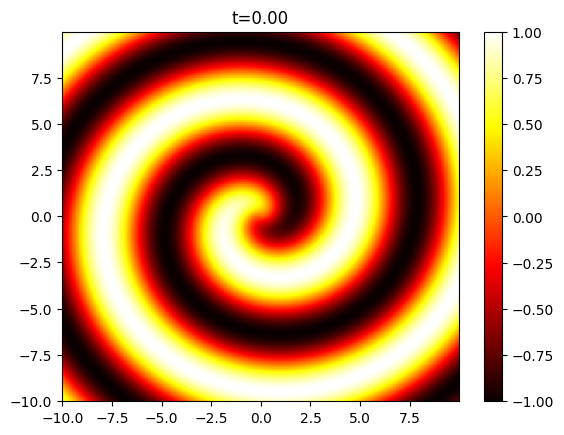

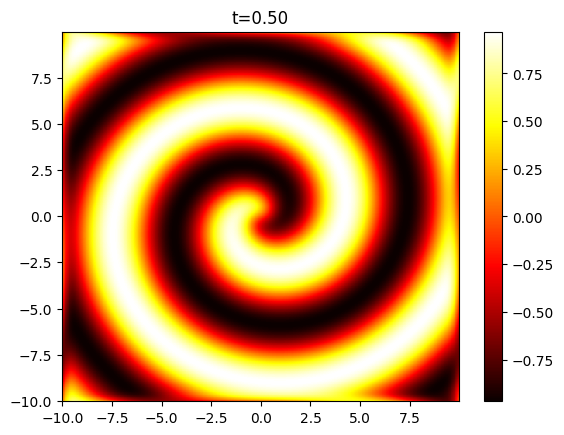

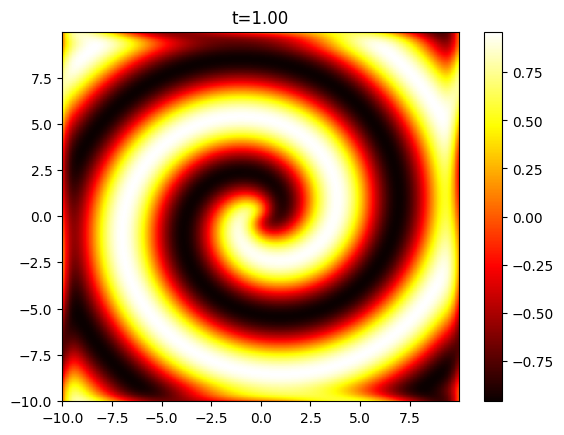

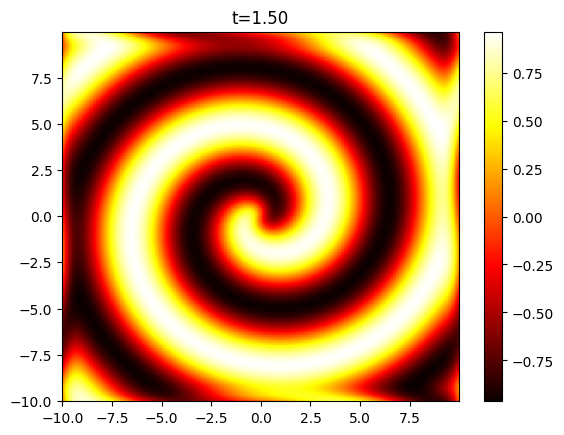

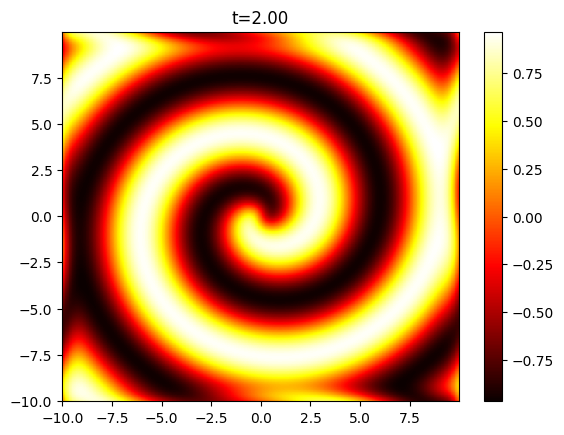

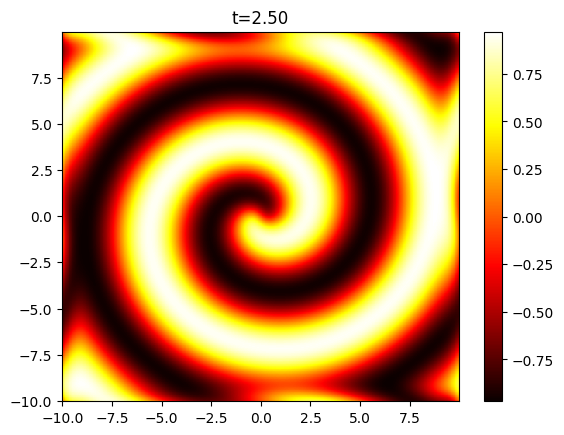

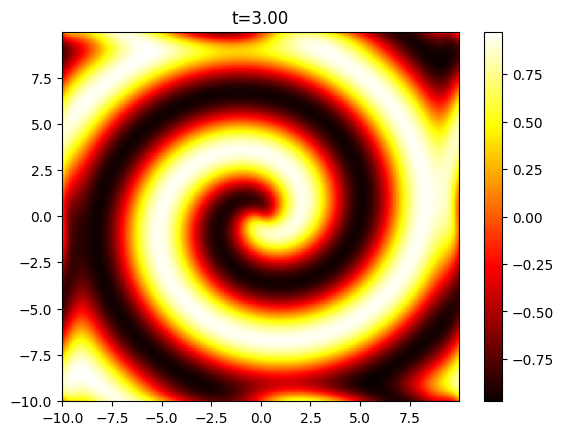

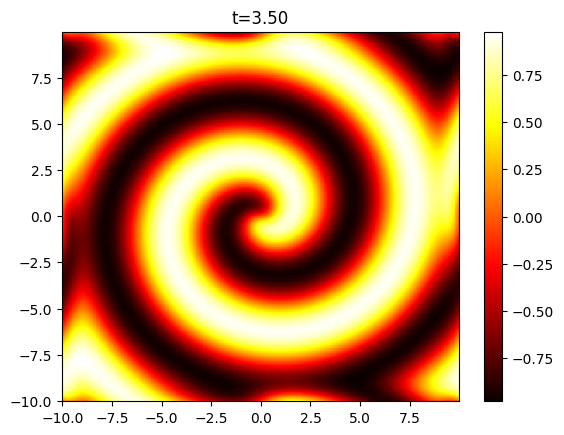

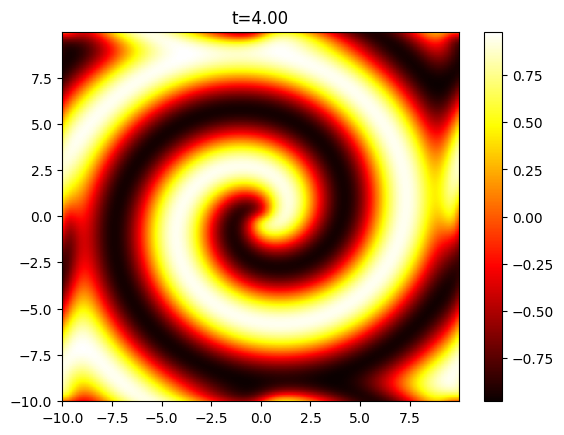

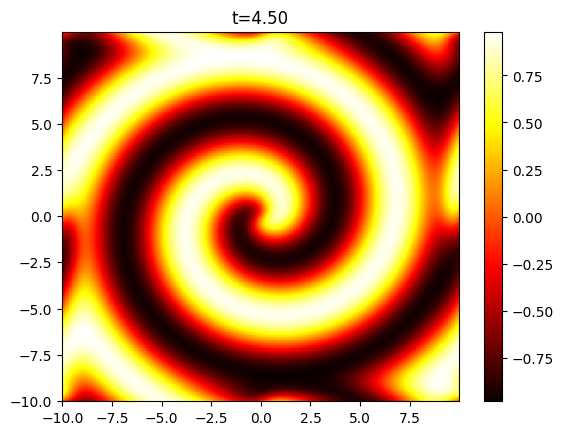

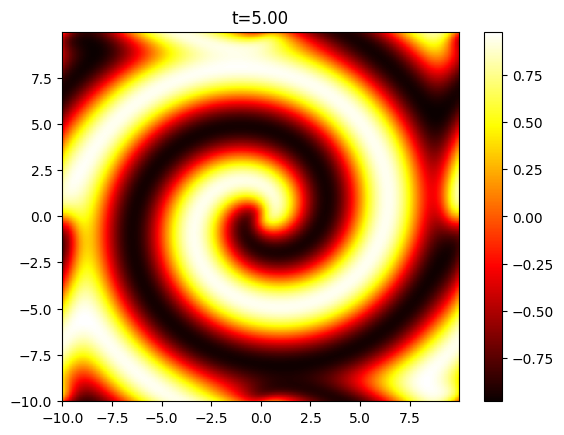

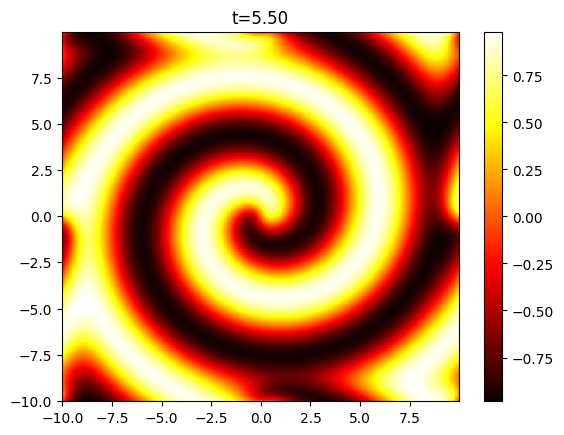

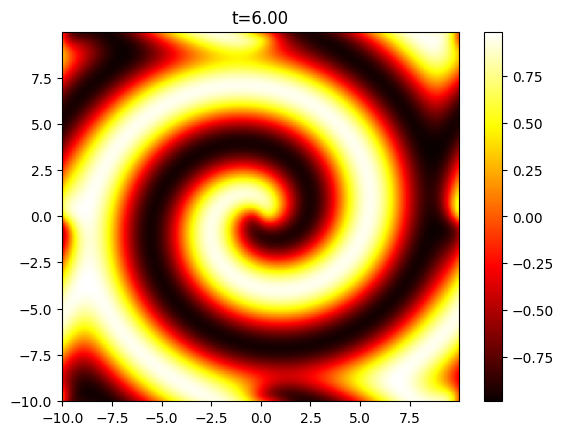

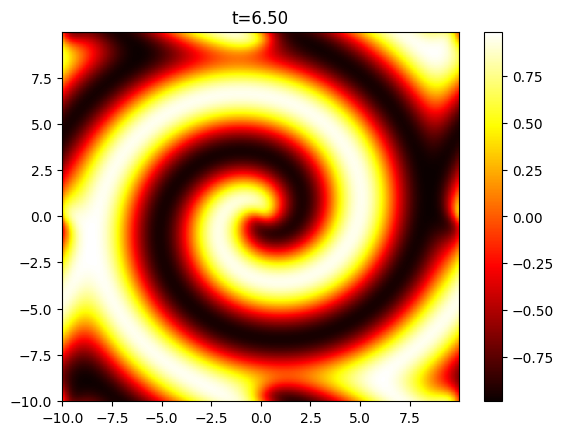

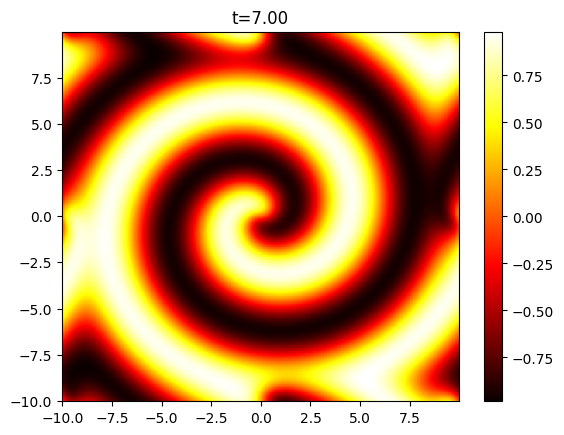

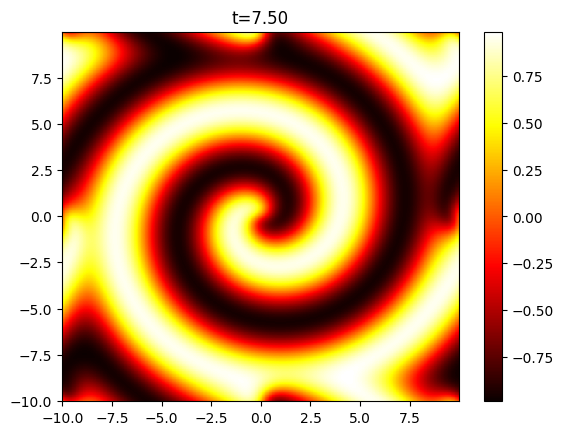

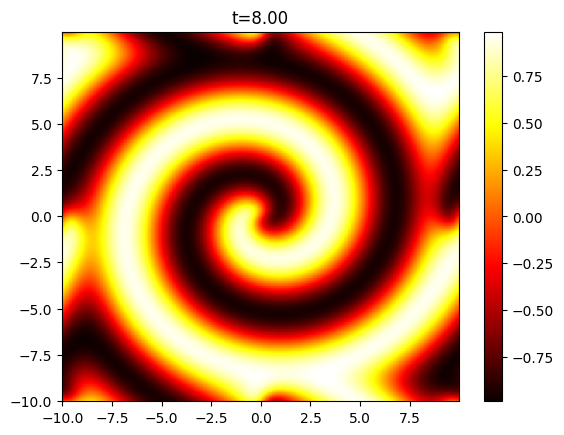

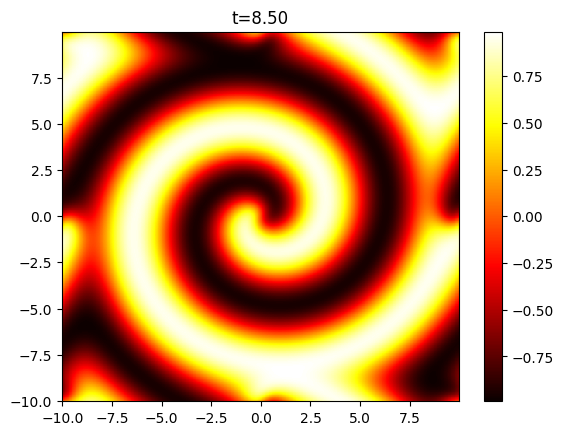

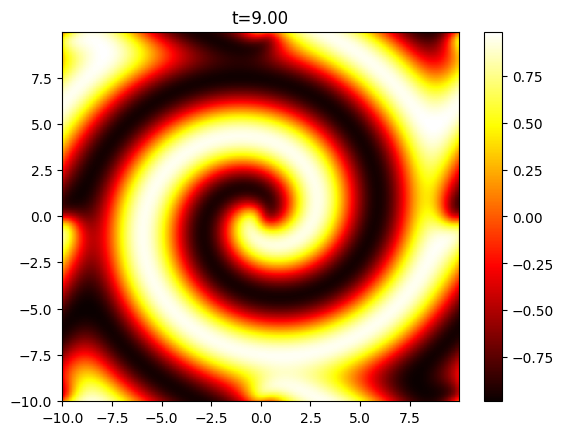

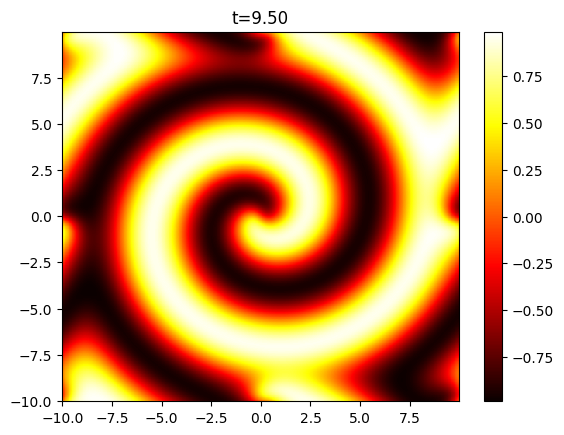

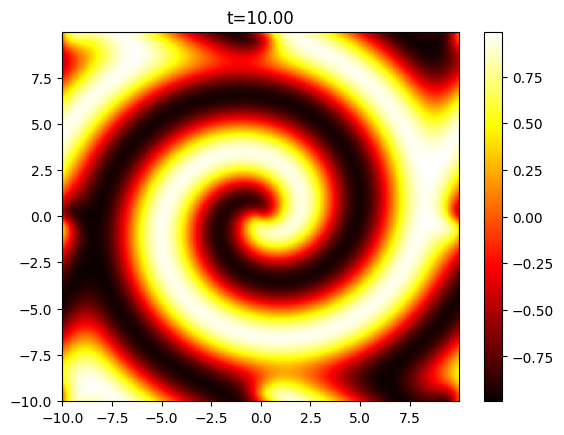

FileNotFoundError: [Errno 2] No such file or directory: 'data/reaction_diffusion_big.mat'

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

# Parameters
t_span = (0, 10)
dt = 0.05
t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
d1 = 0.1
d2 = 0.1
beta = 1.0
L = 20
n = 512
N = n * n
x2 = np.linspace(-L/2, L/2, n+1)
x = x2[:n]
y = x.copy()
kx = (2 * np.pi / L) * np.concatenate([np.arange(0, n//2), np.arange(-n//2, 0)])
ky = kx.copy()

# Initial conditions
X, Y = np.meshgrid(x, y)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K22 = K2.reshape(N, 1)

m = 1  # number of spirals
u0 = np.tanh(np.sqrt(X**2 + Y**2)) * np.cos(m * np.angle(X + 1j * Y) - np.sqrt(X**2 + Y**2))
v0 = np.tanh(np.sqrt(X**2 + Y**2)) * np.sin(m * np.angle(X + 1j * Y) - np.sqrt(X**2 + Y**2))

def reaction_diffusion_rhs(t, uv, K22, d1, d2, beta, n, N):
    u_hat = uv[:N]
    v_hat = uv[N:]
    u = np.fft.ifft2(u_hat.reshape(n, n)).real
    v = np.fft.ifft2(v_hat.reshape(n, n)).real
    A2 = u**2 + v**2
    lam = 1 - A2
    ome = -beta * A2
    u_rhs = lam * u - ome * v
    v_rhs = ome * u + lam * v
    u_rhs_hat = np.fft.fft2(u_rhs) - d1 * K2 * u_hat.reshape(n, n)
    v_rhs_hat = np.fft.fft2(v_rhs) - d2 * K2 * v_hat.reshape(n, n)
    return np.concatenate([u_rhs_hat.reshape(-1), v_rhs_hat.reshape(-1)])

uvt0 = np.concatenate([np.fft.fft2(u0).reshape(-1), np.fft.fft2(v0).reshape(-1)])

sol = solve_ivp(
    reaction_diffusion_rhs, t_span, uvt0, t_eval=t_eval,
    args=(K22, d1, d2, beta, n, N), method='RK45'
)

u = np.zeros((n, n, len(t_eval)))
v = np.zeros((n, n, len(t_eval)))
# for j in range(len(t_eval)):
#     ut = sol.y[:N, j].reshape(n, n)
#     vt = sol.y[N:, j].reshape(n, n)
#     u[:, :, j] = np.fft.ifft2(ut).real
#     v[:, :, j] = np.fft.ifft2(vt).real
#     if j % 10 == 0:
#         plt.figure(1)
#         plt.clf()
#         plt.pcolor(x, y, v[:, :, j], shading='auto', cmap='hot')
#         plt.colorbar()
#         plt.title(f"t={t_eval[j]:.2f}")
#         plt.pause(0.01)

# Save data
import scipy.io as sio
sio.savemat('data/reaction_diffusion_big.mat', {'t': t_eval, 'x': x, 'y': y, 'u': u, 'v': v})

# Plot final state
plt.figure()
plt.pcolor(x, y, u[:, :, -1], shading='auto', cmap='hot')
plt.colorbar()
plt.title("u at final time")
plt.show()

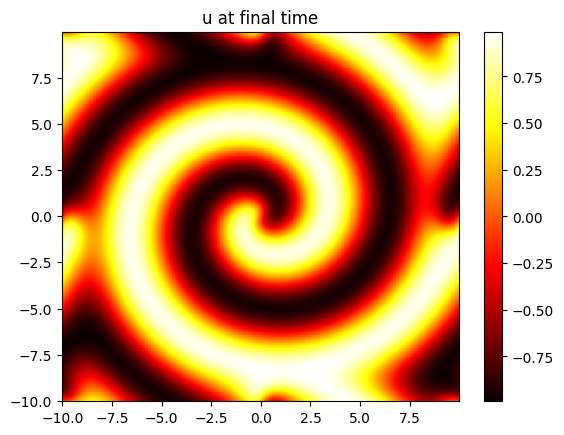

In [9]:
sio.savemat('../Data/reaction_diffusion_big.mat', {'t': t_eval, 'x': x, 'y': y, 'u': u, 'v': v})

# Plot final state
plt.figure()
plt.pcolor(x, y, u[:, :, -1], shading='auto', cmap='hot')
plt.colorbar()
plt.title("u at final time")
plt.show()

In [10]:
data = sio.loadmat('../Data/reaction_diffusion_big.mat')

u = data['u']
v = data['v']
x = data['x'][0]
y = data['y'][0]
t = data['t'][0]
dt = t[1] - t[0]
dx = x[1] - x[0]


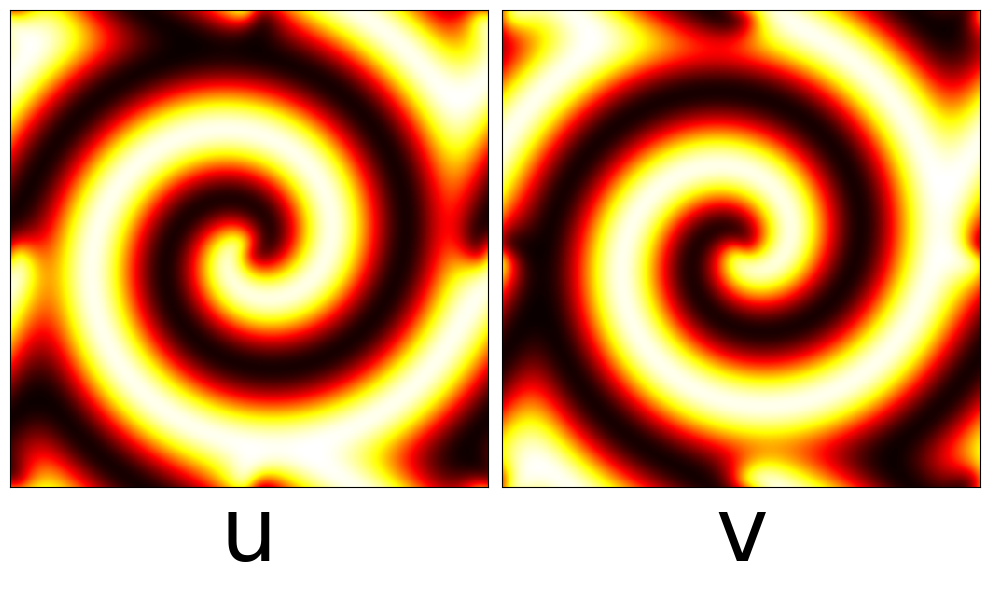

In [16]:
X, T = np.meshgrid(x, t)
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(121)

ax1.pcolor(x, y, u[:, :, -1], shading='auto', cmap='hot')
# plt.title('Burgers Equation', fontsize = 20)

ax1.set_xlabel('u', fontsize = 64)
ax2 = fig.add_subplot(122, sharey=ax1)

ax2.pcolor(x, y, v[:, :, -1], shading='auto', cmap='hot')
# plt.title('Burgers Equation', fontsize = 20)

ax2.set_xlabel('v', fontsize = 64)
# ax2.set_ylabel('t', fontsize = 32)
ax1.set_aspect('equal')
ax2.set_aspect('equal')

ax1.set_xticks([])
ax1.set_yticks([])

ax2.set_xticks([])
ax2.set_yticks([])
fig.tight_layout()

fig.savefig('Figs/rd_equation_example.png', dpi=1200, format='png', bbox_inches='tight')
